# Real observations: climate and image intensity

The photograph is a real image; its sparse sensors are synthetic. NASA annual temperature anomalies are actual climate observations, with a simulated missing-year mask. This notebook uses a cached NASA snapshot when available and otherwise downloads it. Network failure is not hidden by a synthetic substitute.

**Objective:** preserve provenance and units while comparing reconstruction to a reference.

In [1]:
from pathlib import Path
import os
if Path.cwd().name == 'tutorials': os.chdir('..')
import numpy as np
import matplotlib.pyplot as plt
from fieldlab import Grid, points, lines, footprints, projections, combine
from fieldlab.fields import simulate, sensor_layout
from fieldlab.operators import observe
from fieldlab.models import idw, tikhonov, gaussian_process, total_variation, heat_reconstruction


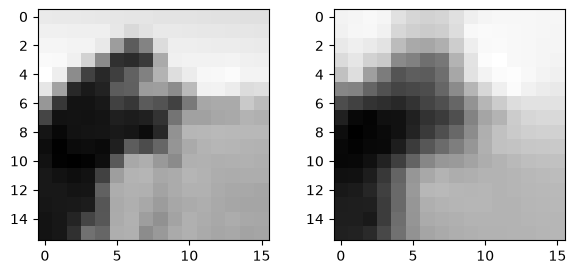

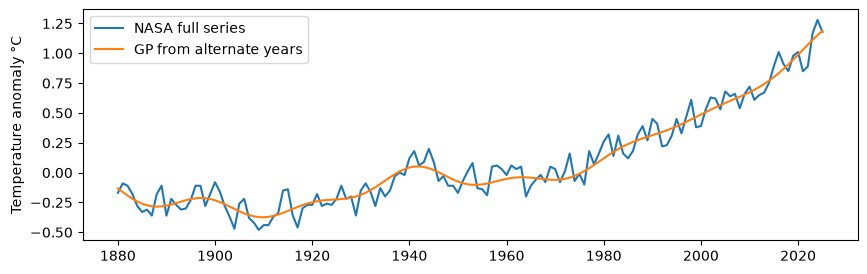

{'source': 'https://data.giss.nasa.gov/gistemp/tabledata_v4/GLB.Ts+dSST.csv', 'units': 'deg C anomaly relative to 1951–1980', 'sha256': '4c64eda288bce32b8d76926278f346ecea1e53506df8ee72a3d5accb0657c416', 'count': 146, 'note': 'Real annual series; missing-year mask in tutorial is simulated.'}


In [2]:
from fieldlab.data import camera_field,nasa_temperature
grid=Grid((16,16)); image=camera_field(grid.shape); A,_=sensor_layout(grid,seed=8)
y=observe(A,image,.03,9); r=tikhonov(grid,A,y)
fig,axes=plt.subplots(1,2,figsize=(7,3)); axes[0].imshow(image,cmap='gray'); axes[1].imshow(r.mean,cmap='gray'); plt.show()
years,temp,metadata=nasa_temperature()
grid1=Grid((len(years),)); idx=np.arange(0,len(years),2)
A1=points(grid1,(idx/(len(years)-1))[:,None]); r1=gaussian_process(grid1,A1,temp[idx],noise=.08,length_scale=.08)
plt.figure(figsize=(10,3)); plt.plot(years,temp,label='NASA full series'); plt.plot(years,r1.mean,label='GP from alternate years'); plt.ylabel('Temperature anomaly °C'); plt.legend(); plt.show()
print(metadata)


**Exercise:** use a consecutive missing decade instead of alternate years. Does random-mask accuracy predict gap accuracy? For the photograph, compare a model trained on blobs against sharp image edges. Cite NASA and distinguish assumed noise from official error bars.

See [theory notes](../docs/theory.md) for assumptions and equations.